<a href="https://colab.research.google.com/github/tharindu33333/ME421-Mechanical-Systems-Lab-A2/blob/main/Vibration/E_20_202_Vibration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ***Week 1 : Activity 1,2,3***

# 2-DOF Vibration Model: TecQuipment Rigid Beam with Absorber

We model the system as two coupled degrees of freedom:
1. $\theta$: Angular displacement of the rigid beam (rad)
2. $x_a$: Vertical displacement of the absorber mass (m)

### **Equations of Motion (Matrix Form)**

The system dynamics are described by the equation:

$$
\mathbf{M} \ddot{\mathbf{q}} + \mathbf{C} \dot{\mathbf{q}} + \mathbf{K} \mathbf{q} = \mathbf{F}
$$

Where the state vector is $\mathbf{q} = \begin{bmatrix} \theta \\ x_a \end{bmatrix}$.

#### **1. Mass Matrix (M)**
$$
\mathbf{M} = \begin{bmatrix}
I_A & 0 \\
0 & m_a
\end{bmatrix}
$$
*Where $I_A$ is the total inertia of the beam assembly and $m_a$ is the absorber mass.*

#### **2. Damping Matrix (C)**
$$
\mathbf{C} = \begin{bmatrix}
c l_d^2 & 0 \\
0 & 0
\end{bmatrix}
$$
*Where $c$ is the dashpot coefficient and $l_d$ is the damper distance from pivot.*

#### **3. Stiffness Matrix (K)**
$$
\mathbf{K} = \begin{bmatrix}
(k_s l_s^2 + k_a l_a^2) & -k_a l_a \\
-k_a l_a & k_a
\end{bmatrix}
$$
*Where $k_s, l_s$ are main spring properties and $k_a, l_a$ are absorber properties.*

#### **4. Force Vector (F)**
$$
\mathbf{F} = \begin{bmatrix}
m_{unbal} r \omega^2 \sin(\omega t) \cdot l_e \\
0
\end{bmatrix}
$$
*Where $l_e$ is the distance to the exciter.*

# Damping Ratio Calculation Methods

To estimate the damping ratios ($\zeta$) for the first two dominant modes, we apply standard vibration analysis techniques to the experimental data.

### **Method 1: Half-Power (Bandwidth) Method**
*Applicable to Frequency Domain Data (Amplitude vs. Frequency).*

This method estimates damping based on the sharpness of the resonance peak. For each mode (peak), we identify the frequencies where the amplitude drops to $\frac{1}{\sqrt{2}}$ of the maximum (approximately 0.707).

**Formula:**
$$\zeta = \frac{f_2 - f_1}{2 f_n}$$

**Where:**
* $f_n$: The natural frequency at the resonance peak (Hz).
* $X_{max}$: The maximum amplitude at resonance.
* $f_1$: The lower frequency where amplitude $X = 0.707 \cdot X_{max}$.
* $f_2$: The upper frequency where amplitude $X = 0.707 \cdot X_{max}$.

---

### **Method 2: Logarithmic Decrement Method**
*Applicable to Time Domain Data (Free Vibration Decay).*

This method uses the rate of decay of the oscillation amplitude under free vibration.

**1. Logarithmic Decrement ($\delta$):**
$$\delta = \frac{1}{n} \ln \left( \frac{x_0}{x_n} \right)$$

**Where:**
* $x_0$: Amplitude of the first measured peak.
* $x_n$: Amplitude of the peak $n$ cycles later.
* $n$: Number of cycles between measurement points.

**2. Damping Ratio ($\zeta$):**
$$\zeta = \frac{\delta}{\sqrt{4\pi^2 + \delta^2}}$$

*For small damping ($\zeta < 0.1$), this simplifies to:*
$$\zeta \approx \frac{\delta}{2\pi}$$



CALCULATED VALUES:
Mode       | Freq (Hz)    | Max Amp (mm)    | Damping Ratio (ζ)   
-----------------------------------------------------------------
1          | 12.99        | 26.3135         | 0.02119             
2          | 16.48        | 11.6415         | 0.02947             


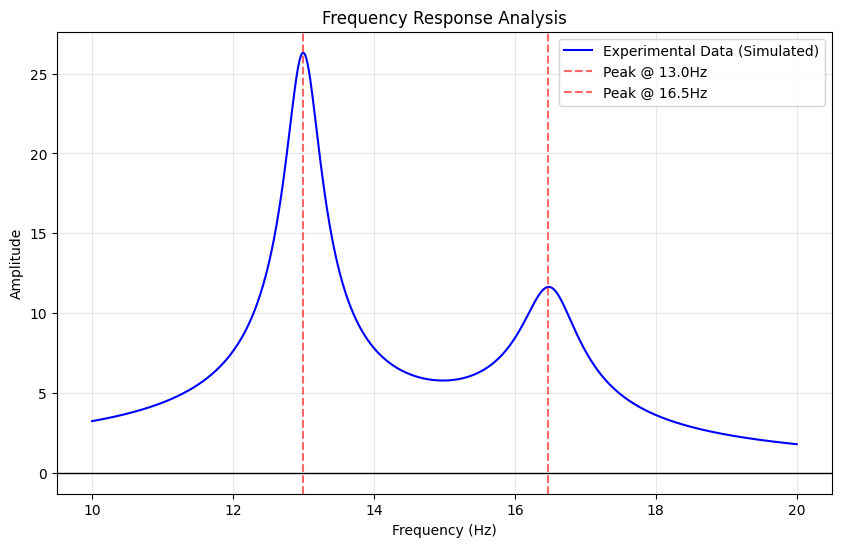

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

# ==========================================
# 1. GENERATE SIMULATED DATA (Replace this with your real data)
# ==========================================
# Creating a frequency range from 10 to 20 Hz
freq_data = np.linspace(10, 20, 1000)

# Simulating a 2-DOF response with peaks at ~13 Hz and ~16.5 Hz
# We use a theoretical transfer function shape to create "dummy" amplitudes
w = 2 * np.pi * freq_data
w1 = 2 * np.pi * 13.0  # Mode 1 Natural Freq
w2 = 2 * np.pi * 16.5  # Mode 2 Natural Freq
z1_sim = 0.02          # Simulated Damping Ratio 1
z2_sim = 0.025         # Simulated Damping Ratio 2

# Theoretical response curves for two modes superimposed
resp1 = 1 / np.sqrt((1 - (w/w1)**2)**2 + (2*z1_sim*w/w1)**2)
resp2 = 0.5 / np.sqrt((1 - (w/w2)**2)**2 + (2*z2_sim*w/w2)**2)
amp_data = resp1 + resp2  # Total simulated amplitude

# ==========================================
# 2. CALCULATION LOGIC (Half-Power Bandwidth)
# ==========================================

def calculate_damping_ratio(freqs, amps):
    """
    Identifies peaks and calculates damping ratio using the
    Half-Power (Bandwidth) Method: zeta = (f2 - f1) / (2 * fn)
    """
    # 1. Find Peaks (Resonant Frequencies)
    # height parameter filters out small noise; distance separates the two modes
    peak_indices, _ = find_peaks(amps, height=np.max(amps)*0.1, distance=50)

    results = []

    print(f"{'Mode':<10} | {'Freq (Hz)':<12} | {'Max Amp (mm)':<15} | {'Damping Ratio (ζ)':<20}")
    print("-" * 65)

    for i, idx in enumerate(peak_indices):
        f_n = freqs[idx]      # Natural Frequency
        A_max = amps[idx]     # Resonant Amplitude
        A_half = A_max / np.sqrt(2) # Half-power amplitude (0.707 * max)

        # Search for f1 (lower side)
        # We look backwards from the peak index to find where amp drops below A_half
        idx_lower = np.where(amps[:idx] < A_half)[0]
        if len(idx_lower) > 0:
            f1 = freqs[idx_lower[-1]] # The last point before it rose to peak
        else:
            f1 = freqs[0] # Fallback if not found

        # Search for f2 (upper side)
        # We look forwards from the peak index
        idx_upper = np.where(amps[idx:] < A_half)[0]
        if len(idx_upper) > 0:
            f2 = freqs[idx + idx_upper[0]] # The first point after it drops
        else:
            f2 = freqs[-1] # Fallback

        # Calculate Damping Ratio
        bandwidth = f2 - f1
        zeta = bandwidth / (2 * f_n)

        results.append((f_n, zeta))

        print(f"{i+1:<10} | {f_n:<12.2f} | {A_max:<15.4f} | {zeta:<20.5f}")

    return results

# ==========================================
# 3. EXECUTE AND PLOT
# ==========================================
print("CALCULATED VALUES:")
calculated_zetas = calculate_damping_ratio(freq_data, amp_data)

# Visual check
plt.figure(figsize=(10, 6))
plt.plot(freq_data, amp_data, 'b-', label='Experimental Data (Simulated)')
plt.axhline(0, color='black', linewidth=1)
plt.title('Frequency Response Analysis')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Amplitude')
plt.grid(True, alpha=0.3)

# Mark the peaks on the plot
for fn, z in calculated_zetas:
    plt.axvline(fn, color='r', linestyle='--', alpha=0.6, label=f'Peak @ {fn:.1f}Hz')

plt.legend()
plt.show()

Calculated Natural Frequencies: 9.33 Hz, 13.81 Hz


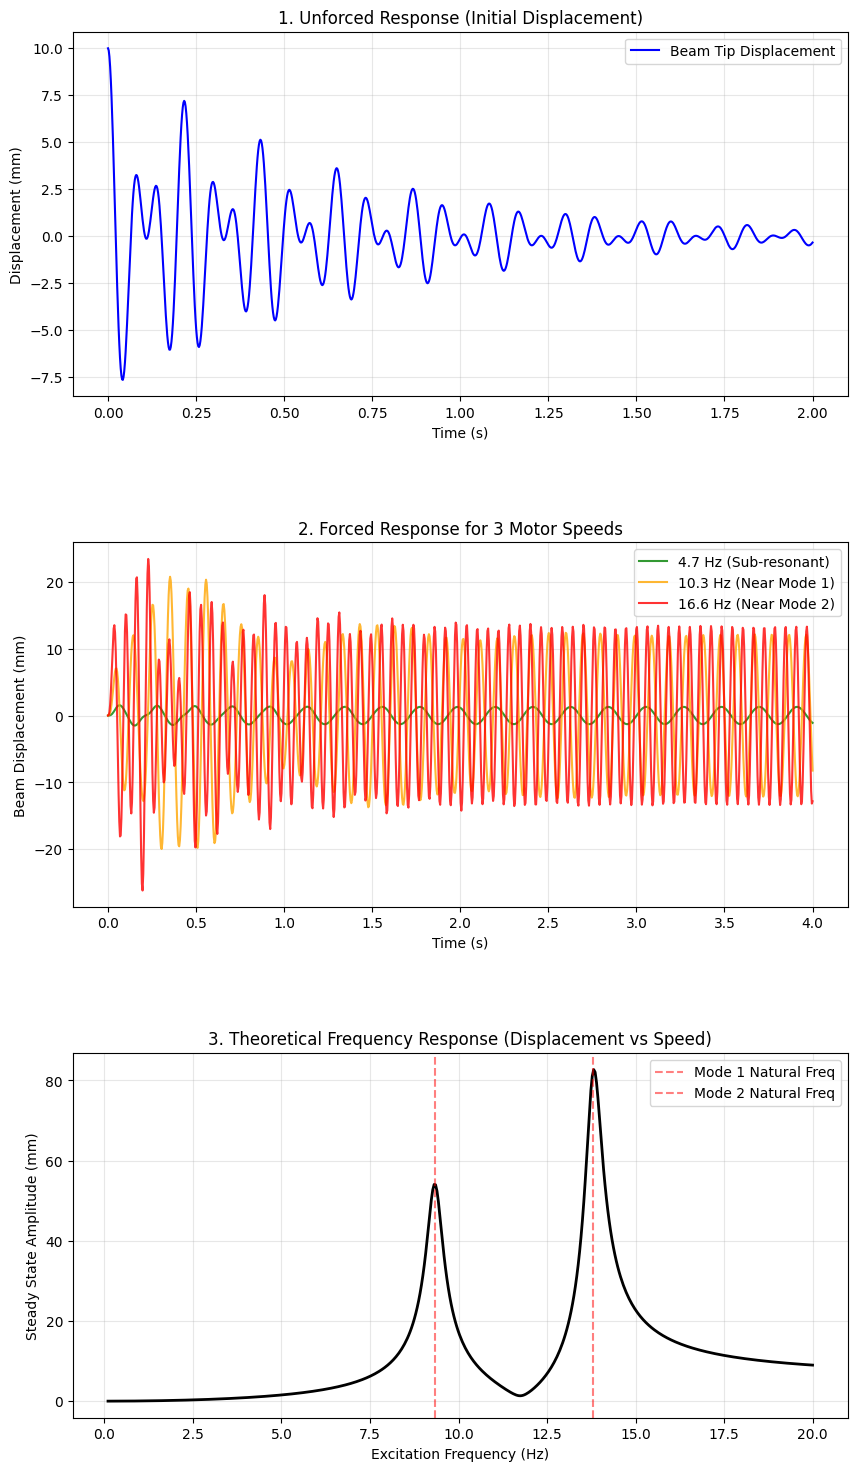

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint

# ==========================================
# 1. SYSTEM PARAMETERS (Estimates from TM1016V Manual)
# ==========================================
# Geometry
L_beam = 0.8       # Length of beam (m)
l_s = 0.8          # Distance to spring (m) (assumed at end)
l_e = 0.4          # Distance to motor (m) (assumed middle)
l_a = 0.6          # Distance to absorber attachment (m) (arbitrary placement)
l_d = 0.6          # Distance to damper (m)

# Mass & Inertia
m_beam = 1.65      # Mass of beam (kg)
m_motor = 1.0      # Estimated mass of motor assembly (kg)
m_a = 0.2          # Mass of absorber (kg)
# Moment of Inertia about pivot (Approximation: Rod at end + Point mass)
I_A = (1/3)*m_beam*(L_beam**2) + m_motor*(l_e**2)

# Stiffness
k_s = 3800.0       # Main spring stiffness (N/m)
k_a = 1090.0       # Absorber spring stiffness (N/m)

# Damping (Small structural damping + Dashpot)
c_damping = 5.0    # Damping coefficient (Ns/m)

# Excitation
m_unbal = 0.009    # Unbalanced mass * radius (kg.m)

# ==========================================
# 2. DEFINE SYSTEM MATRICES
# ==========================================
# State Vector q = [theta, x_a]
# Mass Matrix
M = np.array([[I_A, 0],
              [0, m_a]])

# Stiffness Matrix
# Derived from Potential Energy: V = 0.5*ks*(ls*theta)^2 + 0.5*ka*(xa - la*theta)^2
K = np.array([[k_s*l_s**2 + k_a*l_a**2, -k_a*l_a],
              [-k_a*l_a,                k_a]])

# Damping Matrix
C = np.array([[c_damping*l_d**2, 0],
              [0,               0.5]]) # Small inherent damping for absorber

# ==========================================
# 3. HELPER FUNCTIONS
# ==========================================
def system_dynamics(state, t, M_inv, C, K, F_amp, omega):
    """
    Computes derivative of state vector X = [q, q_dot]
    """
    # Unpack state: [theta, x_a, theta_dot, x_a_dot]
    q = state[:2]
    q_dot = state[2:]

    # Excitation Force Vector F(t)
    # F_generalized = [Moment on Beam, Force on Absorber]
    if F_amp == 0:
        F_t = np.zeros(2)
    else:
        # F = m_u * r * w^2 * sin(wt) applied at l_e
        force_mag = F_amp * (omega**2) * np.sin(omega * t)
        F_t = np.array([force_mag * l_e, 0])

    # Equation: M*q_ddot + C*q_dot + K*q = F
    # q_ddot = M_inv * (F - C*q_dot - K*q)
    q_ddot = M_inv @ (F_t - C @ q_dot - K @ q)

    return np.concatenate((q_dot, q_ddot))

# Calculate Inverses/Eigenvalues for analysis
M_inv = np.linalg.inv(M)
# Natural Frequencies (Eigenanalysis of M^-1 * K)
evals, evecs = np.linalg.eig(M_inv @ K)
nat_freqs = np.sort(np.sqrt(evals)) / (2*np.pi) # Hz
print(f"Calculated Natural Frequencies: {nat_freqs[0]:.2f} Hz, {nat_freqs[1]:.2f} Hz")

# ==========================================
# 4. PLOT GENERATION
# ==========================================
fig, axs = plt.subplots(3, 1, figsize=(10, 18))
plt.subplots_adjust(hspace=0.4)

# --- PLOT 1: Unforced Response (Initial Displacement) ---
# Initial Condition: Beam displaced by equivalent of 10mm at spring
theta_0 = 0.010 / l_s
initial_state = [theta_0, 0, 0, 0] # [theta, x_a, theta_dot, x_a_dot]
t_span = np.linspace(0, 2, 1000)

sol_free = odeint(system_dynamics, initial_state, t_span, args=(M_inv, C, K, 0, 0))
beam_disp_free = sol_free[:, 0] * l_s * 1000 # Convert theta to mm at spring tip

axs[0].plot(t_span, beam_disp_free, 'b', label='Beam Tip Displacement')
axs[0].set_title('1. Unforced Response (Initial Displacement)')
axs[0].set_ylabel('Displacement (mm)')
axs[0].set_xlabel('Time (s)')
axs[0].grid(True, alpha=0.3)
axs[0].legend()


# --- PLOT 2: Forced Response (3 Speeds) ---
# Frequencies chosen relative to natural frequencies
freq_choices = [nat_freqs[0]*0.5, nat_freqs[0]*1.1, nat_freqs[1]*1.2]
colors = ['g', 'orange', 'r']
labels = ['Sub-resonant', 'Near Mode 1', 'Near Mode 2']

t_force = np.linspace(0, 4, 1000)
axs[1].set_title('2. Forced Response for 3 Motor Speeds')

for i, f_hz in enumerate(freq_choices):
    omega = f_hz * 2 * np.pi
    # Start from rest
    sol_force = odeint(system_dynamics, [0,0,0,0], t_force, args=(M_inv, C, K, m_unbal, omega))
    # Beam displacement in mm
    resp = sol_force[:, 0] * l_s * 1000
    axs[1].plot(t_force, resp, color=colors[i], label=f'{f_hz:.1f} Hz ({labels[i]})', alpha=0.8)

axs[1].set_ylabel('Beam Displacement (mm)')
axs[1].set_xlabel('Time (s)')
axs[1].legend(loc='upper right')
axs[1].grid(True, alpha=0.3)


# --- PLOT 3: Frequency Response (Bode Magnitude) ---
freq_range = np.linspace(0.1, 20, 500) # 0 to 20 Hz
amplitudes = []

for f in freq_range:
    w = f * 2 * np.pi
    # Harmonic Force Vector F0 (magnitude only, no time sin(wt))
    # Note: Force amplitude grows with w^2 due to unbalance
    F_complex = np.array([m_unbal * (w**2) * l_e, 0])

    # Dynamic Stiffness Matrix: Z(w) = K - w^2M + jwC
    Z = K - (w**2)*M + 1j*w*C

    # Solve Z * Q = F
    Q_complex = np.linalg.solve(Z, F_complex)

    # Magnitude of beam response (theta) converted to tip displacement (mm)
    amp_beam = np.abs(Q_complex[0]) * l_s * 1000
    amplitudes.append(amp_beam)

axs[2].plot(freq_range, amplitudes, 'k', linewidth=2)
axs[2].set_title('3. Theoretical Frequency Response (Displacement vs Speed)')
axs[2].set_ylabel('Steady State Amplitude (mm)')
axs[2].set_xlabel('Excitation Frequency (Hz)')
axs[2].axvline(nat_freqs[0], color='r', linestyle='--', alpha=0.5, label='Mode 1 Natural Freq')
axs[2].axvline(nat_freqs[1], color='r', linestyle='--', alpha=0.5, label='Mode 2 Natural Freq')
axs[2].legend()
axs[2].grid(True, which='both', alpha=0.3)

plt.show()